In [70]:
# Built-in
import json
import os
import datetime


# Data
import joblib
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Tracking
import wandb

# Scikit-learn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC

In [71]:
# Đọc dữ liệu từ bộ train bằng pandas
data_df = pd.read_csv('../data/train.csv', index_col='PassengerId')

In [72]:
# Chọn target cần dự đoán
target = 'Survived'

In [73]:
# Tách target ra
x = data_df.drop(columns=[target])
y = data_df[target]

In [74]:
# Dùng train_test_split để phân chia dữ liệu
X_train, X_test, Y_train, Y_test = train_test_split(
    x, y, train_size=0.8, random_state=1, stratify=y
)

In [75]:
# Tách Title từ tên sau đó gom nhóm lại 
X_train['Title'] = X_train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
X_test['Title'] = X_test['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

title_mapping = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']

for data in [X_train, X_test]:
    data['Title'] = data['Title'].replace(title_mapping)
    data['Title'] = data['Title'].replace(rare_titles, 'Rare')

In [76]:
# Tạo Deck từ dữ liệu Cabin
X_train['Deck'] = X_train['Cabin'].apply(lambda x: 'U' if pd.isna(x) else str(x)[0])
X_test['Deck'] = X_test['Cabin'].apply(lambda x: 'U' if pd.isna(x) else str(x)[0])

In [77]:
# Phân chia loại dữ liệu 
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
cate_nor_feature = ['Sex', 'Embarked', 'Title', 'Deck']
cate_or_feature = ['Pclass']

In [78]:
# Tạo pipeline cho từng loại feature
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_nor_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
categorical_or_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[[1, 2, 3]]))
])

In [79]:
# Gộp preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat_nor', categorical_nor_transformer, cate_nor_feature),
    ('cat_ord',categorical_or_transformer, cate_or_feature)
]) 

In [80]:

# Khai báo project và các model cần thử
PROJECT_NAME = "titanic-survival-prediction"
experiments = {
    "logistic_regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "model__C": [0.1, 1, 10]
        }
    },

    "random_forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [3, 5, None]
        }
    },

    "svm": {
        "model": SVC(probability=True, random_state=42),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"]
        }
    }
}

In [81]:
# Khởi tạo các biến để lưu các thông số của model tốt nhất
results = []
best_score = -1
best_pipeline = None
best_name = None
best_params = None

In [82]:
# Kết hợp xử lý dữ liệu và chọn model để huấn luyện
from sklearn.metrics import RocCurveDisplay, roc_auc_score


for model_name, exp in experiments.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", exp["model"])
    ])
# GridSearchCV sẽ giúp tìm ra bộ tham số tốt nhất từ các bộ tham số định nghĩa trước đó
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=exp["params"],
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    with wandb.init(
        project=PROJECT_NAME,
        name=model_name,
        group="model-comparison",
        config={
            "model": model_name,
            "params": exp["params"],
            "cv": 5,
            "scoring": "accuracy"
        }
    ) as run:

        grid_search.fit(X_train, Y_train)

        y_pred = grid_search.predict(X_test)
        y_prob = grid_search.predict_proba(X_test)[:, 1]


        test_accuracy = accuracy_score(Y_test, y_pred)
        test_precision = precision_score(Y_test, y_pred)
        test_recall = recall_score(Y_test, y_pred)
        test_f1 = f1_score(Y_test, y_pred)
        test_auc  = roc_auc_score(Y_test, y_prob)

        metrics = {
            "best_cv_accuracy": grid_search.best_score_,
            "test_accuracy": test_accuracy,
            "test_precision": test_precision,
            "test_recall": test_recall,
            "test_f1": test_f1,
            "test_auc": test_auc
        }
        run.log(metrics)
        # Vẽ Ma trận nhầm lẫn cho từng model
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(
            Y_test,
            y_pred,
            display_labels=["Not Survived", "Survived"],
            ax=ax
        )
        ax.set_title(f"Confusion Matrix - {model_name}")
        path_img = f"../screenshots/Confusion Matrix - {model_name}.png"
        plt.savefig(path_img)
        run.log({"confusion_matrix": wandb.Image(path_img)})
        plt.close(fig)

        # Vẽ ROC Curve
        fig, ax = plt.subplots(figsize=(6, 5))
        RocCurveDisplay.from_estimator(
            grid_search.best_estimator_, X_test, Y_test, ax=ax
        )
        ax.set_title(f"ROC Curve — {model_name} (AUC={test_auc:.3f})")
        path_img = f"../screenshots/ROC - {model_name}.png"
        plt.savefig(path_img)
        run.log({"ROC Curve": wandb.Image(path_img)})
        plt.close(fig)

       
       # Vẽ learning curve cho từng model
        train_sizes, train_scores, val_scores = learning_curve(
            grid_search.best_estimator_,
            X_train,
            Y_train,
            cv=5,
            scoring="accuracy",
            n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 5)
        )

        train_mean = train_scores.mean(axis=1)
        val_mean = val_scores.mean(axis=1)

        fig, ax = plt.subplots(figsize=(6, 4))

        ax.plot(train_sizes, train_mean, label="Train accuracy")
        ax.plot(train_sizes, val_mean, label="Validation accuracy")

        ax.set_title(f"Learning Curve - {model_name}.png")
        ax.set_xlabel("Training size")
        ax.set_ylabel("Accuracy")
        ax.legend()
        path_img = f"../screenshots/learning_curve_{model_name}.png"
        fig.savefig(path_img)
        plt.close(fig)
        
        run.log({"learning_curve": wandb.Image(str(path_img))})
        
        # Lưu kết quả từng model và chọn model tốt nhất
        results.append({
            "model": model_name,
            "best_cv_accuracy": grid_search.best_score_,
            "test_accuracy": test_accuracy,
            "test_precision": test_precision,
            "test_recall": test_recall,
            "test_f1": test_f1,
            "best_params": str(grid_search.best_params_)
        })

        if grid_search.best_score_ > best_score:
            best_score = grid_search.best_score_
            best_pipeline = grid_search.best_estimator_
            best_name = model_name
            best_params = grid_search.best_params_

best_cv_accuracy,▁
test_accuracy,▁
test_auc,▁
test_f1,▁
test_precision,▁
test_recall,▁
best_cv_accuracy,0.82163
test_accuracy,0.8324
test_auc,0.84552
test_f1,0.77273
test_precision,0.80952


best_cv_accuracy,▁
test_accuracy,▁
test_auc,▁
test_f1,▁
test_precision,▁
test_recall,▁
best_cv_accuracy,0.81596
test_accuracy,0.84916
test_auc,0.85461
test_f1,0.79699
test_precision,0.82812


best_cv_accuracy,▁
test_accuracy,▁
test_auc,▁
test_f1,▁
test_precision,▁
test_recall,▁
best_cv_accuracy,0.82579
test_accuracy,0.84916
test_auc,0.82246
test_f1,0.7907
test_precision,0.85


In [ ]:
# Bảng so sánh đầy đủ các model
results_df = pd.DataFrame(results)
display(results_df.round(4))


,model,best_cv_accuracy,test_accuracy,test_precision,test_recall,test_f1,best_params
0,logistic_regression,0.8216,0.8324,0.8095,0.7391,0.7727,{'model__C': 1}
1,random_forest,0.8160,0.8492,0.8281,0.7681,0.7970,"{'model__max_depth': 5, 'model__n_estimators':..."
2,svm,0.8258,0.8492,0.8500,0.7391,0.7907,"{'model__C': 1, 'model__kernel': 'rbf'}"


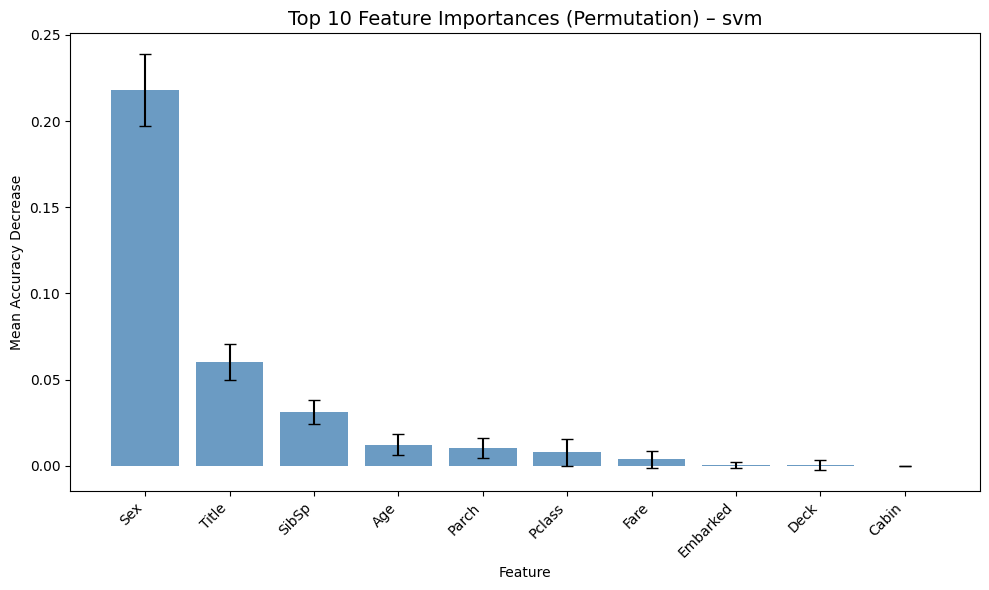

In [84]:
perm = permutation_importance(
    best_pipeline,
    X_test,
    Y_test,
    n_repeats=10,# đảo 10 lần giá trị 
    random_state=42, 
    scoring='accuracy'
)

feature_names = X_test.columns.tolist()

importances_mean = perm.importances_mean
importances_std  = perm.importances_std

# Sắp xếp giảm dần
sorted_idx = importances_mean.argsort()[::-1]

# Top 10
top_n = min(10, len(feature_names))
top_idx = sorted_idx[:top_n]

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    range(top_n),
    importances_mean[top_idx],
    yerr=importances_std[top_idx],
    color='steelblue',
    alpha=0.8,
    capsize=4
)
ax.set_xticks(range(top_n))
ax.set_xticklabels(
    [feature_names[i] for i in top_idx],
    rotation=45, ha='right'
)
ax.set_title(f"Top {top_n} Feature Importances (Permutation) – {best_name}", fontsize=14)
ax.set_ylabel("Mean Accuracy Decrease")
ax.set_xlabel("Feature")
plt.tight_layout()
plt.savefig('../screenshots/feature_importance.png', dpi=150)
plt.show()



In [85]:
# Bảng kết quả
print("\n=== Feature Importance Table ===")
for i in top_idx:
    print(f"  {feature_names[i]:<12} : {importances_mean[i]:.4f} ± {importances_std[i]:.4f}")


=== Feature Importance Table ===
  Sex          : 0.2179 ± 0.0209
  Title        : 0.0603 ± 0.0102
  SibSp        : 0.0313 ± 0.0072
  Age          : 0.0123 ± 0.0060
  Parch        : 0.0106 ± 0.0058
  Pclass       : 0.0078 ± 0.0076
  Fare         : 0.0039 ± 0.0050
  Embarked     : 0.0006 ± 0.0017
  Deck         : 0.0006 ± 0.0030
  Cabin        : 0.0000 ± 0.0000


In [86]:
# Lưu toàn độ model và pipeline
joblib.dump(best_pipeline, "best_titanic_pipeline.joblib")

metadata = {
    "project_name": PROJECT_NAME,
    "best_model": best_name,
    "best_cv_accuracy": best_score,
    "best_params": best_params,
    "training_date": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "target": "Survived"
}

with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4, default=str)

results_df = pd.DataFrame(results)
results_df.to_csv("experiment_results.csv", index=False)

Best model: svm
Best CV accuracy: 0.8257854821235103

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       110
           1       0.85      0.74      0.79        69

    accuracy                           0.85       179
   macro avg       0.85      0.83      0.84       179
weighted avg       0.85      0.85      0.85       179

Confusion Matrix:
[[101   9]
 [ 18  51]]


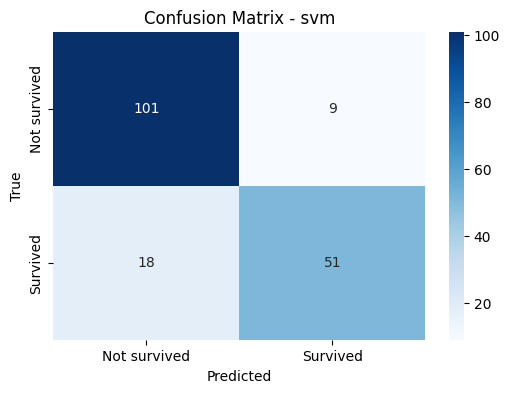

In [87]:
y_pred_best = best_pipeline.predict(X_test)

print("Best model:", best_name)
print("Best CV accuracy:", best_score)

print("\nClassification Report:")
print(classification_report(Y_test, y_pred_best))

print("Confusion Matrix:")
cm = confusion_matrix(Y_test, y_pred_best)
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not survived", "Survived"],
    yticklabels=["Not survived", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

In [88]:
from datetime import datetime
# Tạo thư mục models nếu chưa có
os.makedirs("../models", exist_ok=True)

# Đường dẫn lưu file
MODEL_PATH = "../models/model_package.joblib"
METADATA_PATH = "../models/model_metadata.json"
RESULTS_PATH = "../models/experiment_results.csv"

# 1. Lưu full pipeline
joblib.dump(best_pipeline, MODEL_PATH)
print(f"Đã lưu pipeline: {MODEL_PATH}")

# 2. Lưu metadata
metadata = {
    "project_name": "titanic-survival-prediction",
    "best_model_name": best_name,
    "best_cv_accuracy": float(best_score),
    "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "target": "Survived",
    "models_tried": list(experiments.keys()),
    "best_params": best_pipeline.named_steps["model"].get_params()
}

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, default=str, ensure_ascii=False)

print(f"Đã lưu metadata: {METADATA_PATH}")

# 3. Lưu bảng kết quả
results_df = pd.DataFrame(results)
results_df.to_csv(RESULTS_PATH, index=False, encoding="utf-8-sig")

print(f"Đã lưu results: {RESULTS_PATH}")

Đã lưu pipeline: ../models/model_package.joblib
Đã lưu metadata: ../models/model_metadata.json
Đã lưu results: ../models/experiment_results.csv
